# EDA - Archive Training Dataset
## Análisis Exploratorio de Datos - train_u6lujuX_CVtuZ9i.csv

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

## 2. Carga de Datos

In [2]:
import os
p = 'data/archive/train_u6lujuX_CVtuZ9i.csv'
if os.path.exists(p):
    df = pd.read_csv(p)
    print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"\nPrimeras filas:")
    df.head()
else:
    print(f"File not found: {p}. Skipping analysis.")
    df = pd.DataFrame()

Dataset cargado: 614 filas × 13 columnas

Primeras filas:


## 3. Información General

In [3]:
print("Info del dataset:")
df.info()
print("\n" + "="*80 + "\n")
print("Estadísticas descriptivas:")
df.describe()

Info del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


Estadísticas descriptivas:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## 4. Análisis de Valores Faltantes

Valores faltantes:
                  Faltantes  Porcentaje
Credit_History           50    8.143322
Self_Employed            32    5.211726
LoanAmount               22    3.583062
Dependents               15    2.442997
Loan_Amount_Term         14    2.280130
Gender                   13    2.117264
Married                   3    0.488599


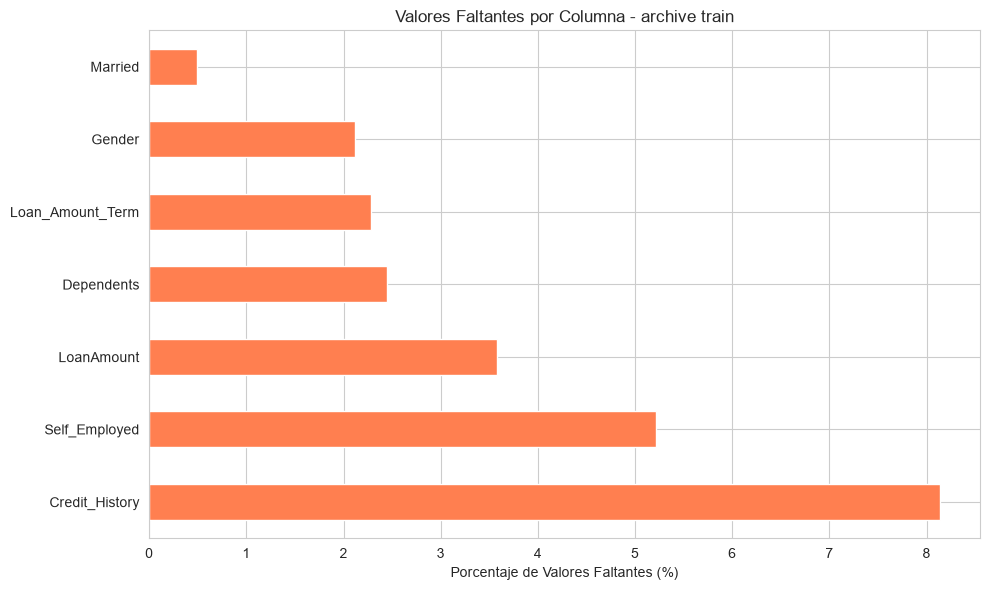

In [4]:
# Valores faltantes
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_percent})
missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

print("Valores faltantes:")
print(missing_df)

# Gráfico de valores faltantes
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    missing_df['Porcentaje'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Porcentaje de Valores Faltantes (%)')
    ax.set_title('Valores Faltantes por Columna - archive train')
    plt.tight_layout()
    plt.show()
else:
    print("No hay valores faltantes en el dataset")

## 5. Análisis por Tipo de Variable

In [5]:
# Separar variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"\nColumnas categóricas ({len(categorical_cols)}): {categorical_cols}")

Columnas numéricas (5): ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Columnas categóricas (8): ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


## 6. Distribuciones de Variables Numéricas

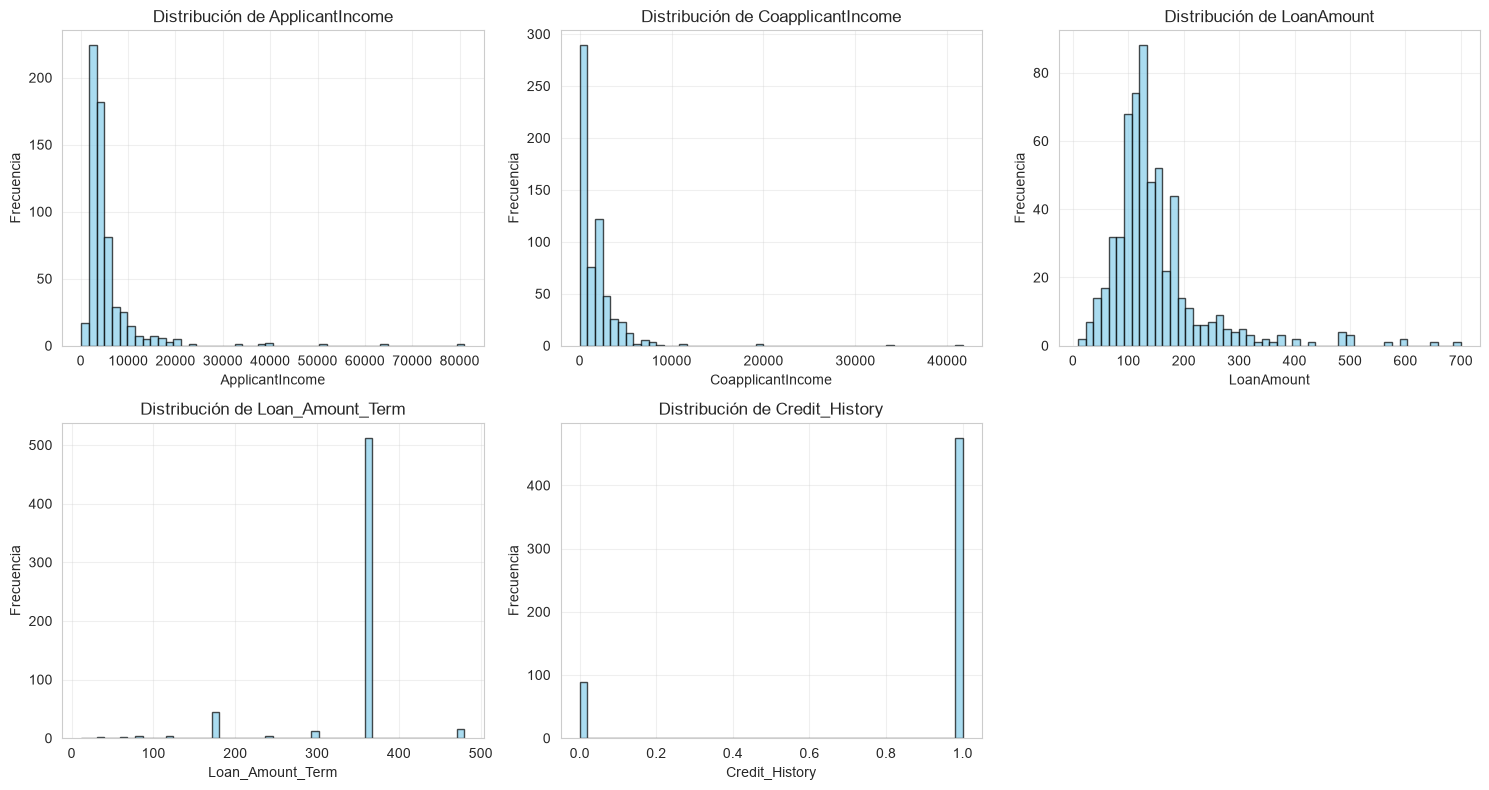

In [6]:
# Histogramas de variables numéricas
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols[:len(axes)]):
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
        axes[idx].set_title(f'Distribución de {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].grid(alpha=0.3)
    
    # Ocultar ejes no usados
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 7. Estadísticas de Correlación

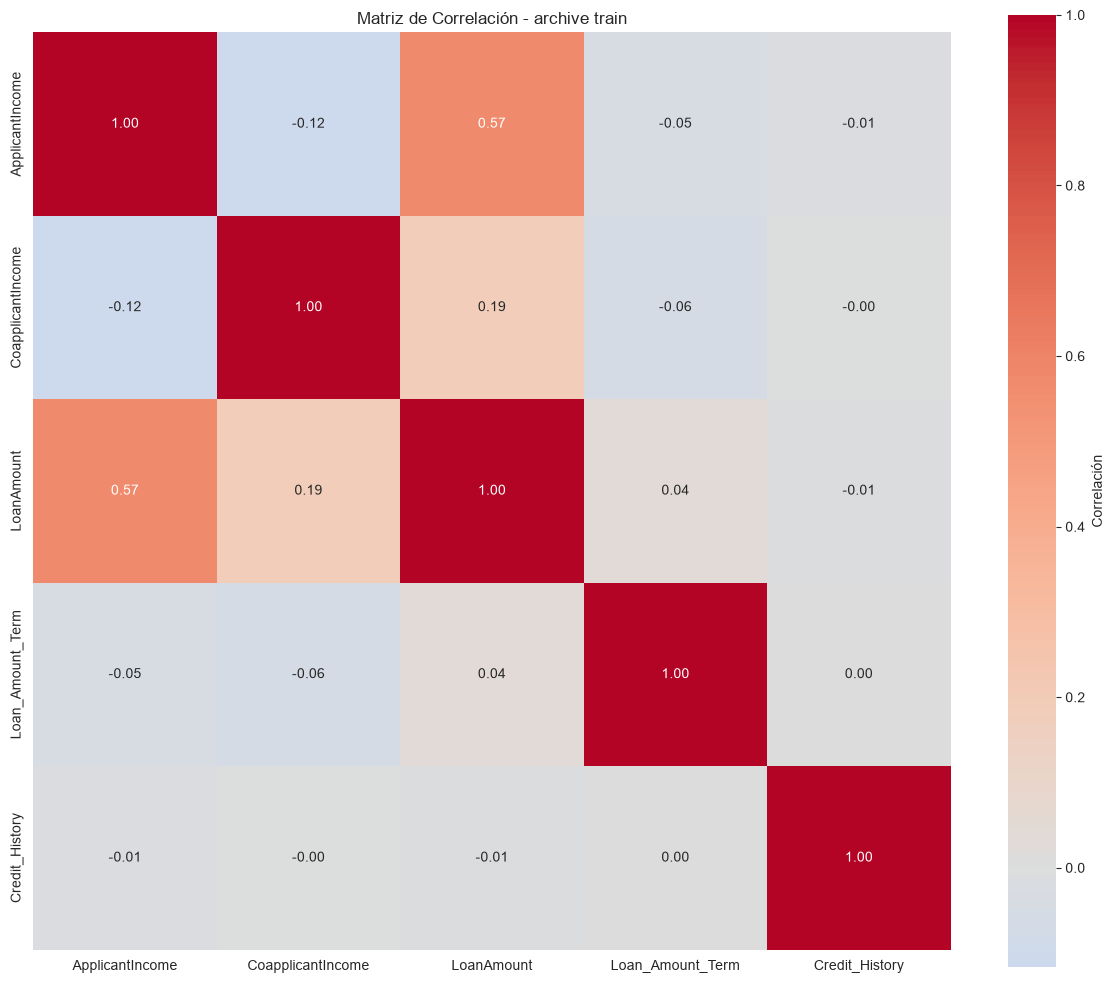

In [7]:
if len(numeric_cols) > 1:
    # Matriz de correlación
    correlation_matrix = df[numeric_cols].corr()
    
    # Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                cbar_kws={'label': 'Correlación'}, square=True)
    plt.title('Matriz de Correlación - archive train')
    plt.tight_layout()
    plt.show()
else:
    print("Insuficientes variables numéricas para matriz de correlación")

## 8. Detección de Outliers

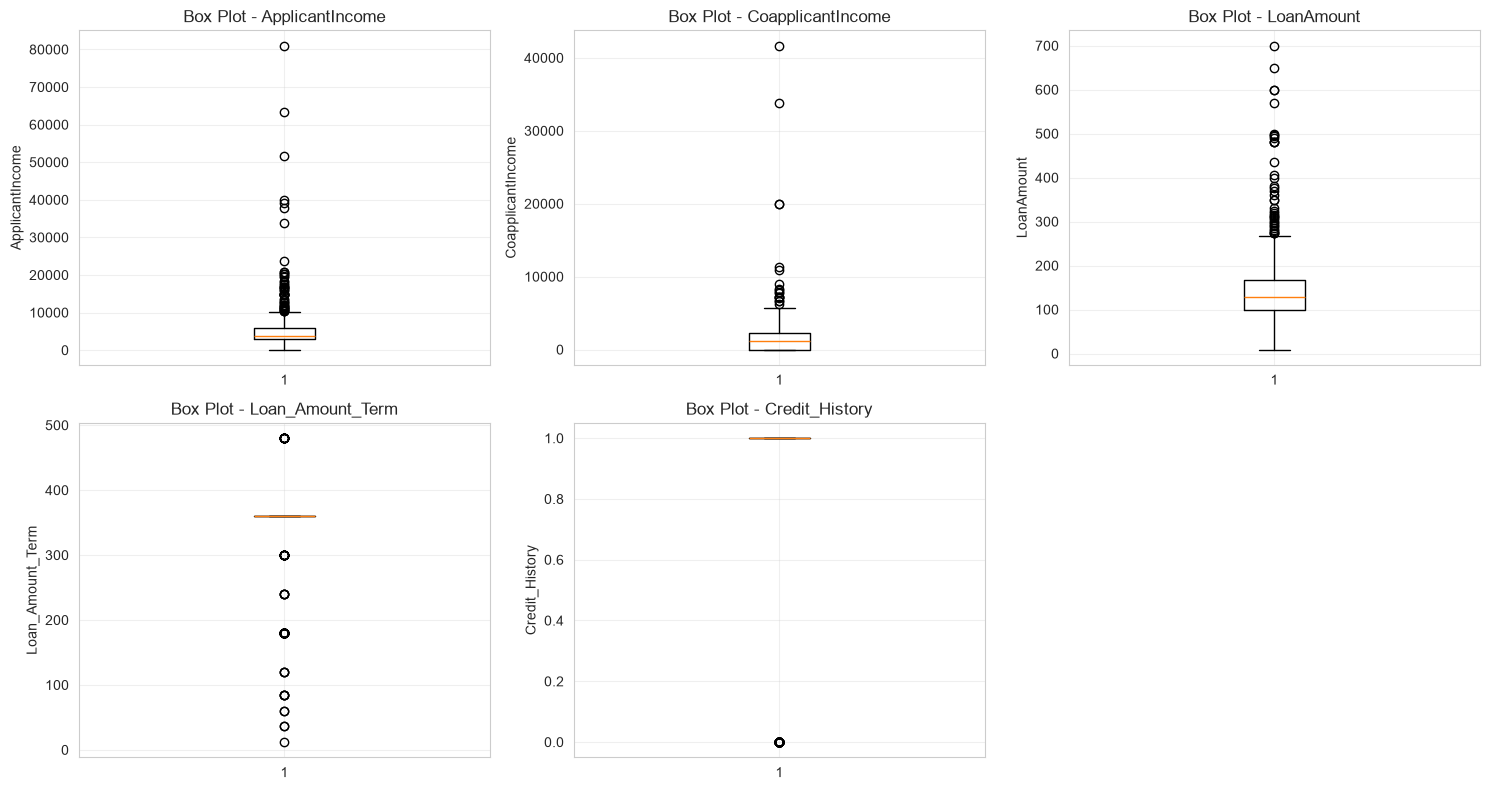

In [8]:
# Box plots para detectar outliers
if numeric_cols:
    numeric_cols_clean = numeric_cols[:6]  # Primeras 6
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for idx, col in enumerate(numeric_cols_clean):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'Box Plot - {col}')
        axes[idx].set_ylabel(col)
        axes[idx].grid(alpha=0.3)
    
    for idx in range(len(numeric_cols_clean), 6):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

## 9. Análisis de Variables Categóricas


Loan_ID:
Loan_ID
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    1
Name: count, Length: 614, dtype: int64


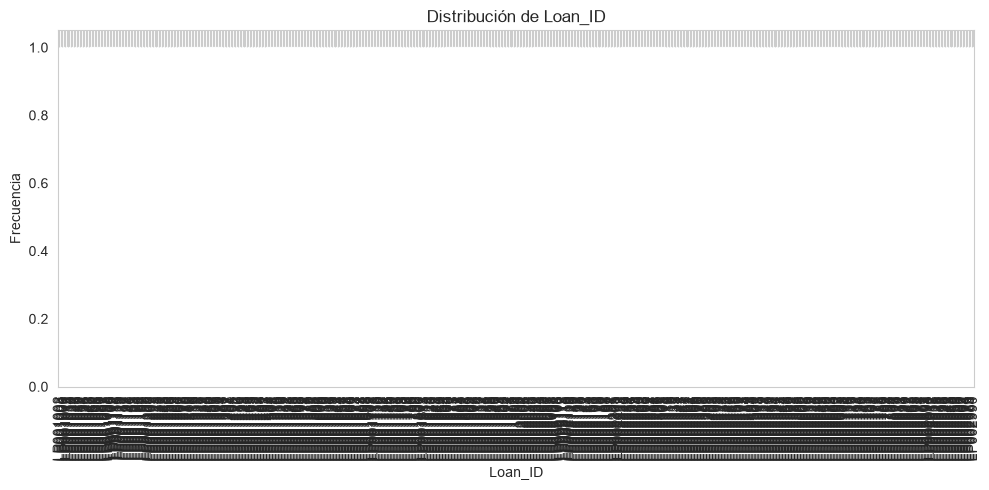


Gender:
Gender
Male      489
Female    112
Name: count, dtype: int64


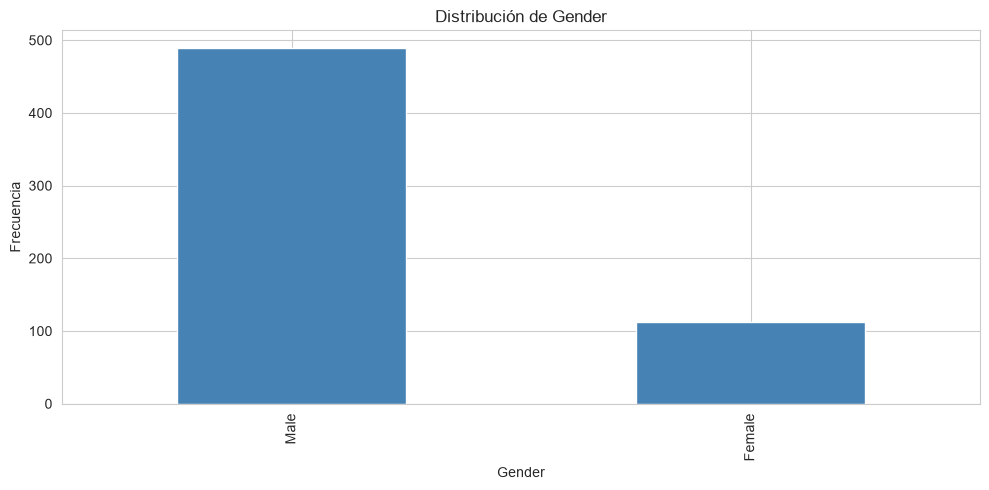


Married:
Married
Yes    398
No     213
Name: count, dtype: int64


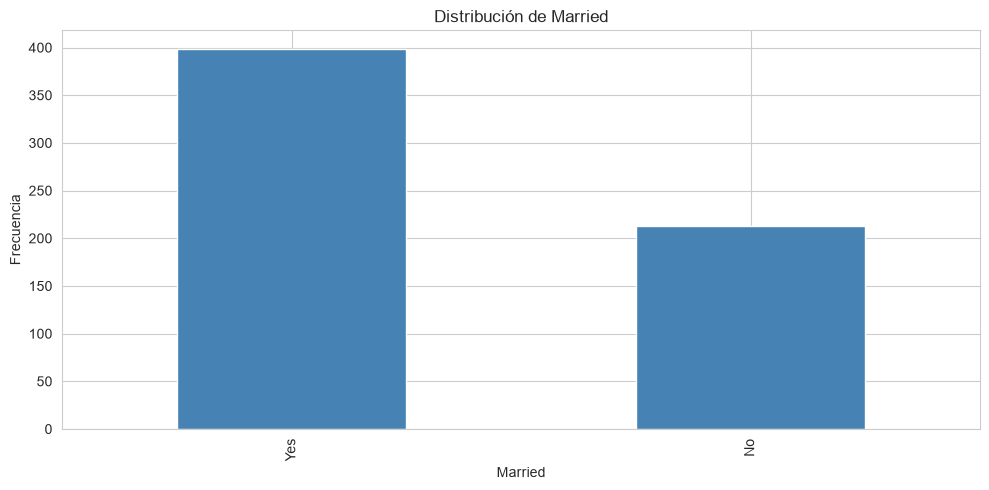


Dependents:
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


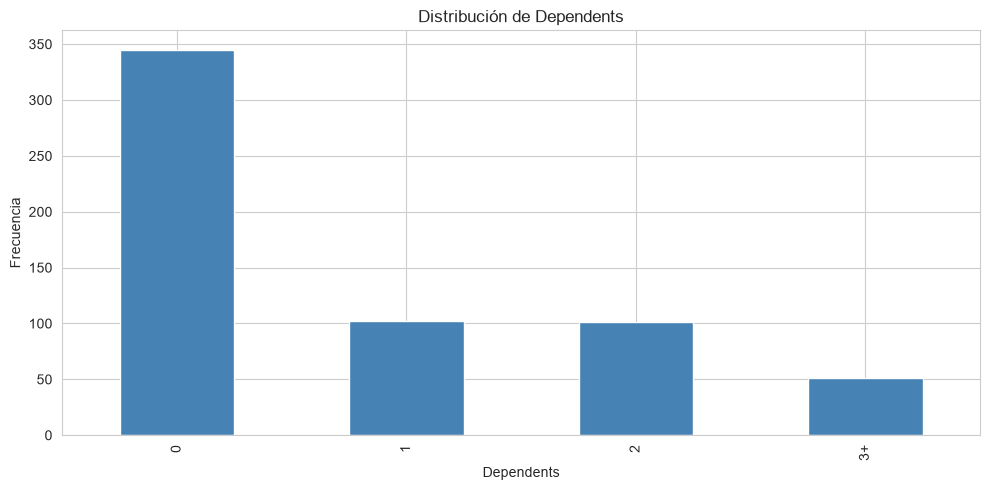

In [9]:
if categorical_cols:
    for col in categorical_cols[:4]:
        print(f"\n{col}:")
        print(df[col].value_counts())
        
        # Gráfico
        fig, ax = plt.subplots(figsize=(10, 5))
        df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        plt.tight_layout()
        plt.show()

## 10. Resumen de Hallazgos

In [10]:
print("=" * 80)
print("RESUMEN - DATASET train_u6lujuX_CVtuZ9i.csv")
print("=" * 80)
print(f"\n📊 Tamaño del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n📈 Variables numéricas: {len(numeric_cols)}")
print(f"📂 Variables categóricas: {len(categorical_cols)}")
print(f"\n❌ Filas con valores faltantes: {df.isnull().any(axis=1).sum():,}")
print(f"\n✅ Filas completas: {len(df) - df.isnull().any(axis=1).sum():,}")
print("\n" + "=" * 80)

RESUMEN - DATASET train_u6lujuX_CVtuZ9i.csv

📊 Tamaño del dataset: 614 filas × 13 columnas

📈 Variables numéricas: 5
📂 Variables categóricas: 8

❌ Filas con valores faltantes: 134

✅ Filas completas: 480

